# Homework #3
## Introduction to deep learning


This colaboratory contains Homework #3 which is due **March 23 midnight (23:59 EET time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

**NB! Links to your colaboratory will not be accepted as a solution!**
## Submission's rules:

1. Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.


##List of Homework's exercises:

1.   [Ex1](#scrollTo=4YtaQwccjrAL) - 6 points
2.   [Ex2](#scrollTo=tOfgGIUtIizt) - 2 points
3.   [Ex3](#scrollTo=rt6Fuo28nQkd) - 2 points
4.   [Bonus 1](#scrollTo=wT-4aQqUtDU7) - 2 points
5.   [Bonus 2](#scrollTo=lEW4oyQhnRQA) - 2 points


In [19]:
# A bit of setup
import numpy as np
import matplotlib.pyplot as plt

Here we will define few functions that will help us visualise classifiers that we are going to build in this class. Don't worry if you don't understand this code completely.

In [20]:
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

# for very shallow models
def plot_classifier(X, y, W, b):
  st = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, st),
                       np.arange(y_min, y_max, st))
  Z = np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b
  Z = np.argmax(Z, axis=1)
  Z = Z.reshape(xx.shape)
  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

# for two-layer network
def plot_neural_network(X, y, W,b ,W2, b2):
  st = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, st),
                       np.arange(y_min, y_max, st))
  Z = np.dot(np.maximum(0, np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b), W2) + b2
  Z = np.argmax(Z, axis=1)
  Z = Z.reshape(xx.shape)
  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

In [21]:
N = 100 # number of points per class
D = 2 # number of features (dimensions)
K = 2 # number of classes (purple and red circles)
X = np.zeros((N*K,D)) # data matrix (each row = single example)
num_examples = X.shape[0]
y = np.zeros((N*K, 1), dtype='int') # class labels

In [22]:
# Creating spiral data points
np.random.seed(1111)

for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix, 0] = j

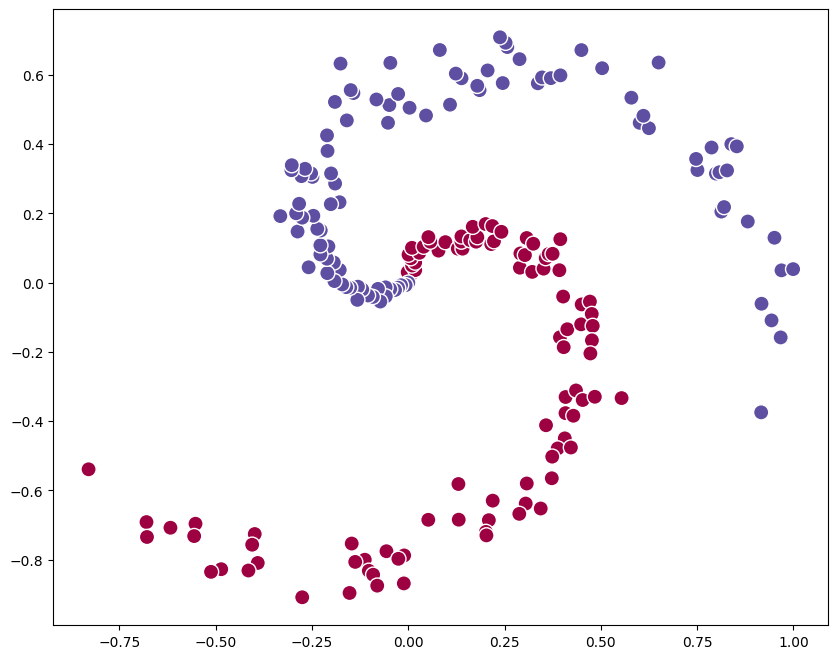

In [23]:
# this is matplotlib...
plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
plt.show()

For our implementation we would need to transform the vector of correct labels `y` into one hot encoded matrix, let's call it `truth`. Сreating `truth` as one-hot encoded labels (`y`)

In [24]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore')
truth = enc.fit_transform(y).toarray()

# first column is for red
# second is for purple class

## Homework exercise 1 (6 points): three-layer network
<font color='red'> Obviously, ~91% that we have received in the classrooom is not good enough for us, add one more layer to the network that we have defined before, by filling in the gaps.</font>

<font color='red'> **(Homework exercise 1- a)** Initialise weights and compute the forward path with 2 hidden layers (each with `h` neurons and followed by the ReLu) and one output layer **(1 point)**. </font>

In [7]:
# initialize parameters randomly
h = 100 # size of hidden layer

# first hidden layer
W = 0.01 * np.random.randn(D,h)
b = np.zeros((1,h))

# What should be the dimensions of the second layer?
##### YOUR CODE STARTS #####
W2 = 0.01 * np.random.randn(h, h)
b2 = np.zeros((1, h))
##### YOUR CODE ENDS #####

# the third layer for the class scores (second layer in previous network)
W3 = 0.01 * np.random.randn(h,K)
b3 = np.zeros((1,K))

In [8]:
hidden_layer = np.maximum(0, X @ W + b) # NB, ReLU activation
print(hidden_layer.shape)

(200, 100)


In [9]:
##### YOUR CODE STARTS #####
hidden_layer_2 = np.maximum(0, hidden_layer @ W2 + b2) # NB, ReLU activation
##### YOUR CODE ENDS #####
print(hidden_layer_2.shape)

(200, 100)


In [10]:
predictions = hidden_layer_2 @ W3 + b3 # Note, no activation function for the last layer!
print(f'the shape of predictions is {predictions.shape}, and it should be (200, 2)')

the shape of predictions is (200, 2), and it should be (200, 2)


Compute the total error as usuall

In [11]:
total_error = 1/2 * np.sum((truth - predictions)**2)
total_error = total_error/num_examples
print(np.round(total_error, 3))

0.5


<font color='red'> **(Homework exercise 1- b)** Calculate `bW`, `db`, `bW2`, `db2`, `bW3` and `db3` usign backpropagation algorithm. **(2 points)** </font>

In [12]:
dTEdP = (truth - predictions)*(-1)
dTEdP /= num_examples

In [13]:
# first backprop to parameters W3 and b3
##### YOUR CODE STARTS #####
dW3 = hidden_layer_2.T @ dTEdP
db3 = np.sum(dTEdP, axis=0, keepdims=True)
##### YOUR CODE ENDS #####

In [14]:
dH2 = dTEdP @ W3.T
# ReLu in the second layer
dH2[hidden_layer_2 <= 0] = 0

In [15]:
# then backprop to parameters W2 and b2
##### YOUR CODE STARTS #####
dW2 = hidden_layer.T @ dH2
db2 = np.sum(dH2, axis=0, keepdims=True)
##### YOUR CODE ENDS #####

In [16]:
##### YOUR CODE STARTS #####
dH = dH2 @ W2.T
# do not forget ReLu
dH[hidden_layer <= 0] = 0
##### YOUR CODE ENDS #####


In [17]:
# finally into W,b
##### YOUR CODE STARTS #####
dW = X.T @ dH
db = np.sum(dH, axis=0, keepdims=True)
##### YOUR CODE ENDS #####

<font color='red'> **(Homework exercise 1- c)** Put together code from **(b)** into a single cell below and run the training **(1 point)** </font>

In [20]:
# initialize parameters randomly
h = 100 # size of hidden layer

# first hidden layer
W = 0.01 * np.random.randn(D,h)
b = np.zeros((1,h))

# What should be the dimensions of the second layer?
##### YOUR CODE STARTS #####
W2 = 0.01 * np.random.randn(h,h)
b2 = np.zeros((1,h))
##### YOUR CODE ENDS #####

# the third layer for the class scores (second layer in previous network)
W3 = 0.01 * np.random.randn(h,K)
b3 = np.zeros((1,K))

# some hyperparameters
learning_rate = 1e-0

# gradient descent loop
num_examples = X.shape[0]
for i in range(2000):
  ##### YOUR CODE STARTS #####

  # forward path
  hidden_layer = np.maximum(0, X @ W + b)
  hidden_layer_2 = np.maximum(0, hidden_layer @ W2 + b2)
  scores = hidden_layer_2 @ W3 + b3

  # compute the error: average sum of squared differences
  exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
  predictions = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
  total_error = -np.sum(truth * np.log(predictions + 1e-8)) / num_examples

  if i % 100 == 0:
    print("iteration %d: loss %e" % (i, total_error))

  # compute the gradient on predictions
  dTEdP = (predictions - truth) / num_examples

  # backprop

  # first backprop into parameters W3 and b3
  dW3 = hidden_layer_2.T @ dTEdP
  db3 = np.sum(dTEdP, axis=0, keepdims=True)

  # then backprop into W2 and b2
  dH2 = dTEdP @ W3.T
  dH2[hidden_layer_2 <= 0] = 0
  dW2 = hidden_layer.T @ dH2
  db2 = np.sum(dH2, axis=0, keepdims=True)

  # finally into W,b
  dH = dH2 @ W2.T
  dH[hidden_layer <= 0] = 0
  dW = X.T @ dH
  db = np.sum(dH, axis=0, keepdims=True)

  # perform a parameter update
  W3 -= learning_rate * dW3
  b3 -= learning_rate * db3
  W2 -= learning_rate * dW2
  b2 -= learning_rate * db2
  W -= learning_rate * dW
  b -= learning_rate * db

  ##### YOUR CODE ENDS #####

iteration 0: loss 6.931471e-01
iteration 100: loss 7.147106e-01
iteration 200: loss 2.240604e-01
iteration 300: loss 1.620133e-01
iteration 400: loss 9.985071e-02
iteration 500: loss 5.811843e-02
iteration 600: loss 5.081073e-02
iteration 700: loss 3.018881e-02
iteration 800: loss 3.862612e-02
iteration 900: loss 2.280219e-02
iteration 1000: loss 2.231203e-02
iteration 1100: loss 2.151053e-02
iteration 1200: loss 2.199973e-02
iteration 1300: loss 1.965179e-02
iteration 1400: loss 1.758230e-02
iteration 1500: loss 1.804338e-02
iteration 1600: loss 1.696994e-02
iteration 1700: loss 1.653709e-02
iteration 1800: loss 1.598871e-02
iteration 1900: loss 1.558992e-02


In [21]:
# evaluate training set accuracy
hidden_layer = np.maximum(0, X @ W + b)
hidden_layer_2 = np.maximum(0, hidden_layer @ W2 + b2) # NB, ReLU activation
predictions = hidden_layer_2 @ W3 + b3
predicted_class = np.argmax(predictions, axis=1)
print('training accuracy: %.2f' % (np.mean(predicted_class == y[:,0])))

training accuracy: 0.99


You should get about 98% of accuracy

<font color='red'> **(Homework exercise 1- d)** Make a new function `plot_deep_neural_network` by altering the code of `plot_neural_network` to visualise obtained model with W, W2, W3 and b, b2, b3 **(1 point)** </font>



In [25]:
def plot_deep_neural_network(X, y, W, b ,W2, b2, W3, b3):
  st = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, st),
                       np.arange(y_min, y_max, st))

  ##### YOUR CODE STARTS #####
  hidden_layer = np.maximum(0, np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b)
  hidden_layer_2 = np.maximum(0, np.dot(hidden_layer, W2) + b2)
  Z = np.dot(hidden_layer_2, W3) + b3
  ##### YOUR CODE ENDS #####

  Z = np.argmax(Z, axis=1)
  Z = Z.reshape(xx.shape)
  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

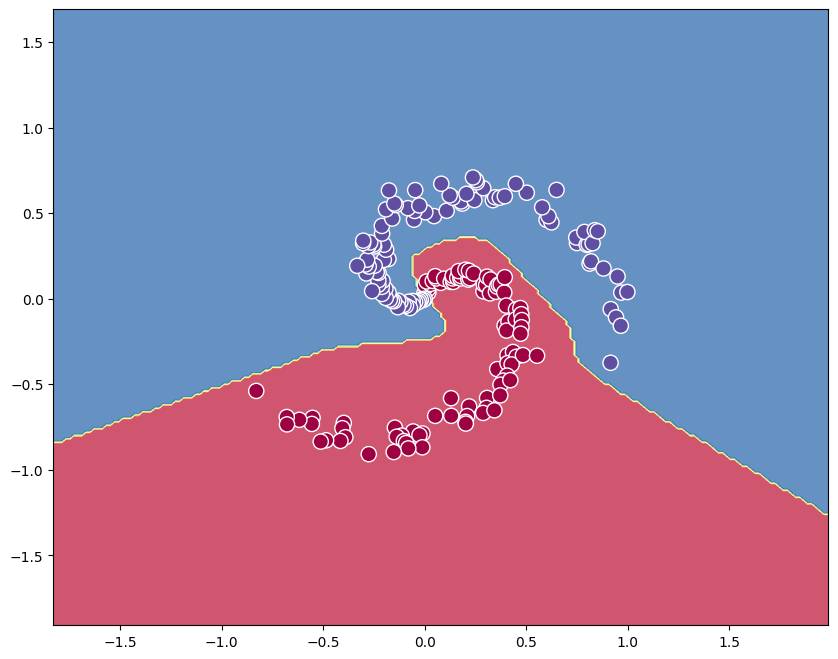

In [23]:
# plot the resulting classifier
plot_deep_neural_network(X, y, W, b, W2, b2, W3, b3)

<font color='red'> **(Homework exercise 1- e)** Interpret obtained plot and accuracy. Did the classifier become more rigid or more flexible? Why? Did the performance of the 3-layer network improve comparing to 2-layer network? **(1 point)** </font>


Answer to **(e)**:

In short: More layers -> more flexibility -> higher accuracy

The classifier became more flexible in the 3-layer network compared to the 2-layer one. This is because the additional hidden layer allows it to learn more complex decision boundaries and better capture the spiral pattern in the data.

The performance improved — the accuracy went from 0.92 to 0.99, meaning the model correctly classified almost all points, and the extra layer helped it generalize better to the training data by refining its decision boundary.

## Homework exercise 2 (2 points): adding and subtracting layers in Keras
<font color='red'> Sometimes you may want to experiment with the number of layers in your network. Adding or subtracting layers is one of the simplest ways to reduce overfitting or improve the performance of your model. Here we will practice adding and remove layers in Keras (feel the difference with pure Python). </font>


In [24]:
# A bit of setup again
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, MaxPooling2D, BatchNormalization, Dropout

# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train data shape:  (25000, 32, 32, 3)
Train labels shape:  (25000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


In [25]:
mu = X_train.mean(axis=(0,1,2)) # finds mean of R, G and B separately
std = X_train.std(axis=(0,1,2)) # same for std
X_train_norm = (X_train - mu)/std
X_test_norm = (X_test - mu)/std

<font color='red'> **(Homework exercise 2- a)** Copy paste to cell below the initial CNN model created for CIFAR10. Next, remove the second Conv2D + BatchNorm + ReLu block and train this smaller network on the same data (make sure to correctly link the layers in the model). Visualise the learning curves. **(1 point)** </font>

In [26]:
##### YOUR CODE STARTS #####
x = Input(shape=(32, 32, 3))
c1 = Conv2D(32, (3, 3), strides=(1, 1), padding="same")(x)
b1 = BatchNormalization()(c1)
a1 = Activation('relu')(b1)
# c2 = Conv2D(32, (3, 3), strides=(1, 1), padding="valid")(a1)
# b2 = BatchNormalization()(c2)
# a2 = Activation('relu')(b2)
p2 = MaxPooling2D(pool_size=2)(a1)
d2 = Dropout(rate=0.25)(p2)
f2 = Flatten()(d2) # tensor into vector
h3 = Dense(100)(f2)
b3 = BatchNormalization()(h3)
a3 = Activation('relu')(b3)
d3 = Dropout(rate=0.5)(a3)
z = Dense(10)(d3)
p = Activation('softmax')(z)
##### YOUR CODE ENDS #####

In [28]:
smaller_model = Model(inputs=x, outputs=p)
smaller_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
smaller_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         819,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 821,734 (3.13 MB)

 Trainable params: 821,470 (3.13 MB)

 Non-trainable params: 264 (1.03 KB)

In [29]:
# Fit the model; returns History object
history_smaller = smaller_model.fit(X_train_norm, y_train, batch_size=64, epochs=20, validation_split=0.1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3367 - loss: 1.9321 - val_accuracy: 0.5104 - val_loss: 1.3732
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5186 - loss: 1.3412 - val_accuracy: 0.5788 - val_loss: 1.1938
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5682 - loss: 1.2098 - val_accuracy: 0.5924 - val_loss: 1.1403
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6062 - loss: 1.1176 - val_accuracy: 0.6292 - val_loss: 1.0625
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6294 - loss: 1.0476 - val_accuracy: 0.6304 - val_loss: 1.0464
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6515 - loss: 1.0034 - val_accuracy: 0.6476 - val_loss: 1.0337
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6688 - loss: 0.9395 - val_accuracy: 0.6376 - val_loss: 1.0150
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6744 - loss: 0.9053 - val_accuracy: 

Text(0.5, 1.0, 'Accuracy')

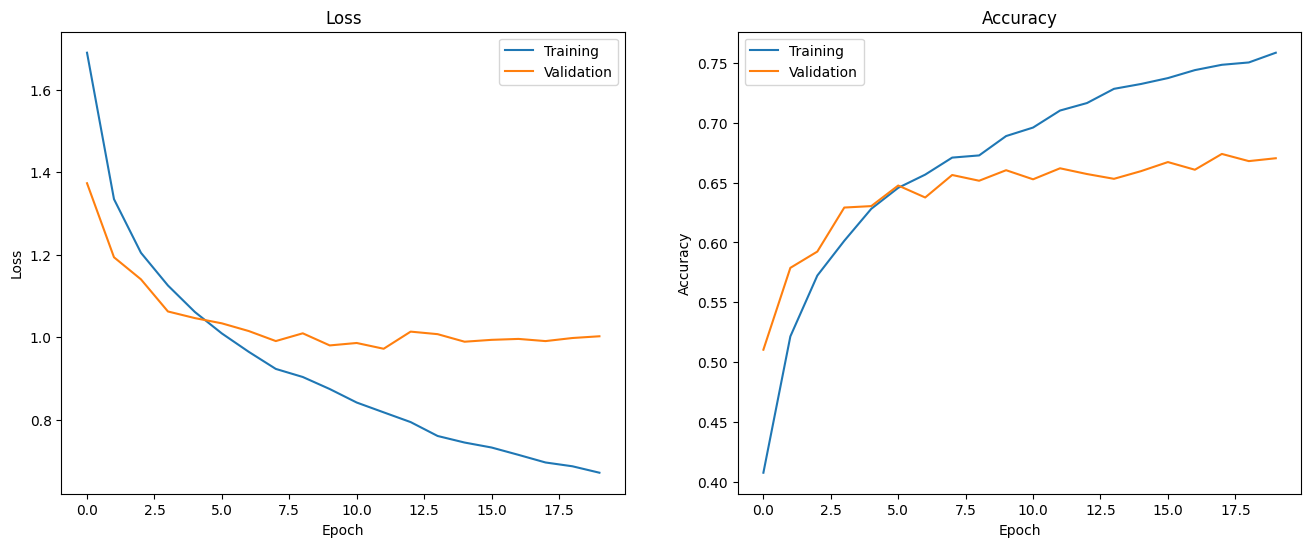

In [30]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history_smaller.history['loss'])
plt.plot(history_smaller.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_smaller.history['accuracy'])
plt.plot(history_smaller.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.title('Accuracy')

<font color='red'> **(Homework exercise 2- b)** Now make a bigger version of the same network, by adding additional Conv2D + BatchNorm + ReLu block. So you should have three Conv2D + BatchNorm + ReLu blocks now. Next train it and visualise learning curves **(0.5 points)**. </font>

In [31]:
##### YOUR CODE STARTS #####
x = Input(shape=(32, 32, 3))

c1 = Conv2D(32, (3, 3), strides=(1, 1), padding="same")(x)
b1 = BatchNormalization()(c1)
a1 = Activation('relu')(b1)

c2 = Conv2D(32, (3, 3), strides=(1, 1), padding="valid")(a1)
b2 = BatchNormalization()(c2)
a2 = Activation('relu')(b2)

c3 = Conv2D(64, (3, 3), strides=(1, 1), padding="same")(a2)
b3 = BatchNormalization()(c3)
a3 = Activation('relu')(b3)

p3 = MaxPooling2D(pool_size=2)(a3)
d3 = Dropout(rate=0.25)(p3)

f3 = Flatten()(d3)
h4 = Dense(100)(f3)
b4 = BatchNormalization()(h4)
a4 = Activation('relu')(b4)
d4 = Dropout(rate=0.5)(a4)

z = Dense(10)(d4)
p = Activation('softmax')(z)
##### YOUR CODE ENDS #####

In [33]:
bigger_model = Model(inputs=x, outputs=p)
bigger_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
bigger_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 30, 30, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │       1,440,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 1,470,662 (5.61 MB)

 Trainable params: 1,470,206 (5.61 MB)

 Non-trainable params: 456 (1.78 KB)

In [34]:
# Fit the model; returns History object
history_bigger = bigger_model.fit(X_train_norm, y_train, batch_size=64, epochs=20, validation_split=0.1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.3652 - loss: 1.8787 - val_accuracy: 0.5596 - val_loss: 1.2745
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5798 - loss: 1.1925 - val_accuracy: 0.6208 - val_loss: 1.0562
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6496 - loss: 1.0002 - val_accuracy: 0.6572 - val_loss: 0.9804
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6813 - loss: 0.9078 - val_accuracy: 0.6564 - val_loss: 0.9892
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7193 - loss: 0.8082 - val_accuracy: 0.6764 - val_loss: 0.9450
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7522 - loss: 0.7118 - val_accuracy: 0.6800 - val_loss: 0.9408
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7702 - loss: 0.6583 - val_accuracy: 0.6892 - val_loss: 0.9144
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7881 - loss: 0.6068 - val_accuracy:

Text(0.5, 1.0, 'Accuracy')

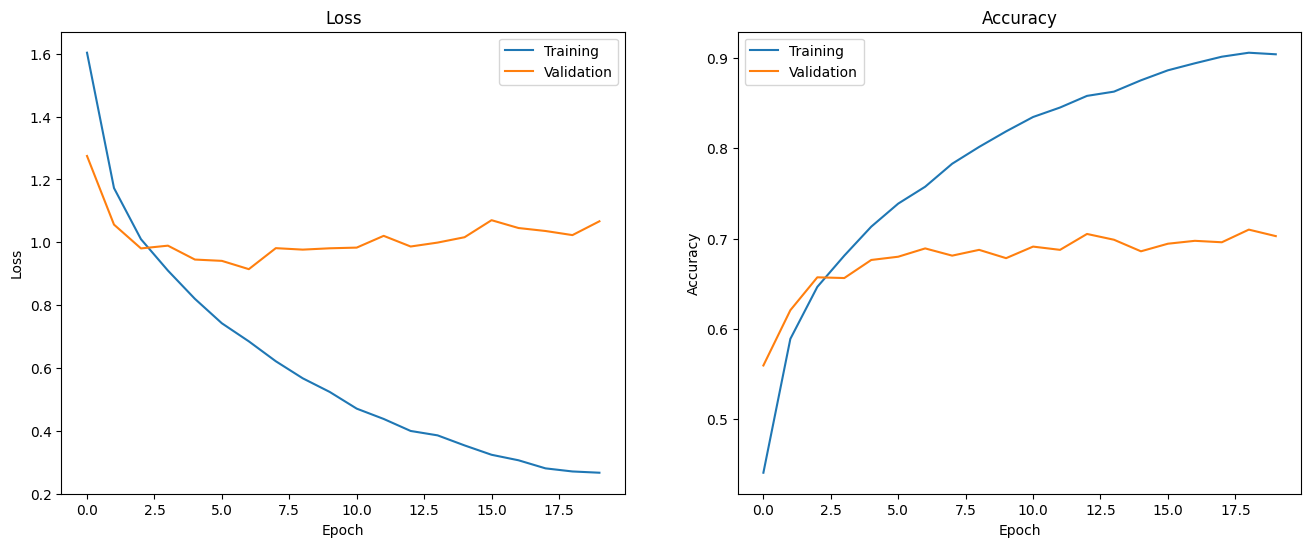

In [35]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history_bigger.history['loss'])
plt.plot(history_bigger.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_bigger.history['accuracy'])
plt.plot(history_bigger.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.title('Accuracy')

<font color='red'> **(Homework exercise 2- c)** Compare learning curves for smaller and bigger versions and say which version has overfitted the data more significantly? Why do you think so? Which network you would run in production? **(0.5 points)**. </font>

Answer to **(c)**:

The bigger network has overfitted more significantly because it memorizes training data too well but struggles to generalize to new data. This is indicated by the large accuracy gap between training and validation and the increasing validation loss after some epochs.

 I would deploy the smaller network in production to ensure better generalization and efficiency with even less computantional costs.

## Homework exercise 3 (2 points): Create your own dataset and build a CNN model using fast.ai API
<font color='red'> In this exercise, you have a chance to test if CNN can distinguish between images of your favourite objects. </font>

In [8]:
!pip install fastai==1.0.61

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.2/239.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.9 MB/s eta 0:00:00
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl

In [12]:
!pip install fastai --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.5/234.5 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: fastai
    Found existing installation: fastai 1.0.61
    Uninstalling fastai-1.0.61:
      Successfully uninstalled fastai-1.0.61


In [9]:
# Some setup first as usual
from fastai.vision import *
from fastai.metrics import error_rate

# We don't like warnings
import warnings
warnings.filterwarnings('ignore')

from urllib.request import urlopen

<font color='red'> **(Homework exercise 3- a)** Create your own dataset with two or more classes using the same approach we used in the class. But this time choose classes yourself. **(1 point)** </font>

In [ ]:
##### YOUR CODE STARTS #####
from google.colab import files
uploaded = files.upload()
##### YOUR CODE ENDS #####

In [8]:
from pathlib import Path

folders = ["bottega_venetta_jodie", "chanel_255"]

for folder in folders:
    path = Path(f'data/{folder}')
    path.mkdir(parents=True, exist_ok=True)

In [20]:
from fastai.vision.utils import download_images

kelly_csv_path = Path("/content/bottega_venetta_jodiecsv")
birkin_csv_path = Path("/content/chanel_255.csv")

kelly_dest = Path("/content/data/bottega_venetta_jodie")
birkin_dest = Path("/content/data/chanel_255")

kelly_dest.mkdir(parents=True, exist_ok=True)
birkin_dest.mkdir(parents=True, exist_ok=True)

download_images(kelly_dest, url_file=kelly_csv_path, max_pics=150)
download_images(birkin_dest, url_file=birkin_csv_path, max_pics=150)

In [21]:
from fastai.vision.utils import verify_images

for folder in folders:
  path = Path(f"/content/data/{folder}")
  print(f"Verifying images in {folder}...")
  verify_images(path)

Verifying images in hermes_kelly...
'PosixPath' object is not iterable
Verifying images in hermes_birkin...
'PosixPath' object is not iterable


In [7]:
import os

for folder in folders:
    path = f"/content/data/{folder}"
    num_images = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
    print(f"{folder}: {num_images} images")

bottega_venetta_jodie: 150 images
chanel_255: 150 images


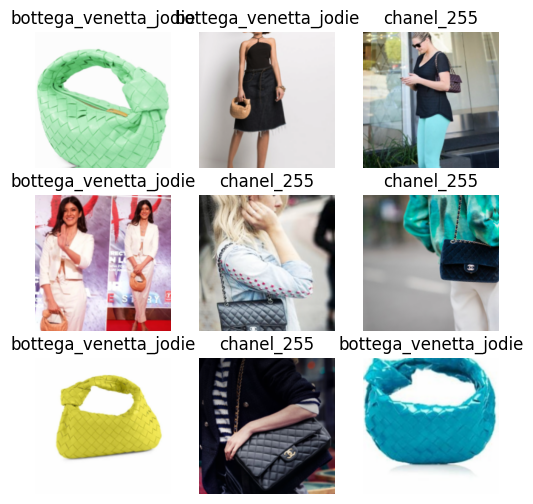

In [2]:
from fastai.vision.all import *

path = Path("/content/data")

dls = ImageDataLoaders.from_folder(
    path, valid_pct=0.2, item_tfms=Resize(224), batch_tfms=aug_transforms()
)

dls.show_batch(max_n=9, figsize=(6,6))

<font color='red'> **(Homework exercise 3- b)** train a neural network on images you have acquired **(0.5 points)** </font>

In [3]:
##### YOUR CODE STARTS #####
learn = cnn_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(3)
##### YOUR CODE ENDS #####

/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 97.5MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.118687,0.854556,0.800000,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.452314,0.654774,0.816667,00:05
1,0.366524,0.386350,0.833333,00:04
2,0.280764,0.300220,0.883333,00:04


Plot the confusion matrix to make sure that you model has learned something:

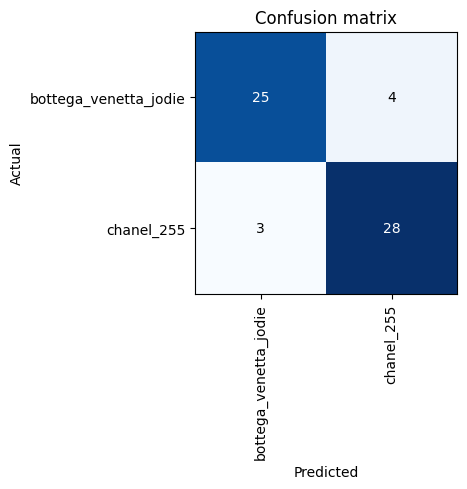

In [4]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

<font color='red'> **(Homework exercise 3- c)** Test your model on one or more images from the internet that represent classes you have chosen, but unlikely to be in the training data (you can change your search query). Print out class probabilities for one of these test images. **(0.5 points)** </font>

In [6]:
test_path = Path("/content/final_bags_test")

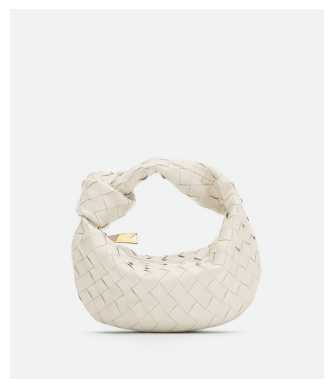

Predicted class: bottega_venetta_jodie
Class probabilities: [0.999713, 0.000286]


In [13]:
##### YOUR CODE STARTS #####
test_img_path = test_path / "bottega_venetta_jodie_test1.jpg"
img = PILImage.create(test_img_path)
plt.imshow(img)
plt.axis("off")
plt.show()
pred_class, pred_idx, probs = learn.predict(img)
print(f"Predicted class: {pred_class}")
print(f"Class probabilities: {[float(f'{p:.6f}') for p in probs.numpy()]}")
##### YOUR CODE ENDS #####


Image: chanel_255_test1.jpg


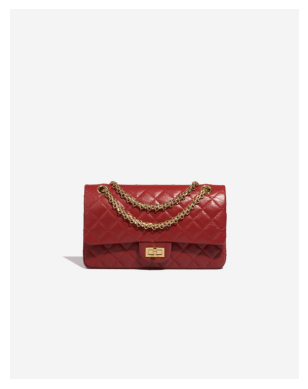

Predicted Class: chanel_255
bottega_venetta_jodie: 0.11%
chanel_255: 99.89%



Image: bottega_venetta_jodie_test2.jpg


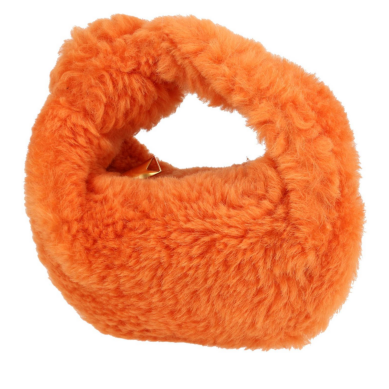

Predicted Class: bottega_venetta_jodie
bottega_venetta_jodie: 99.74%
chanel_255: 0.26%



Image: bottega_venetta_jodie_test3.jpg


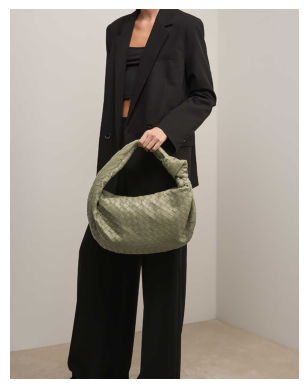

Predicted Class: bottega_venetta_jodie
bottega_venetta_jodie: 98.43%
chanel_255: 1.57%



Image: bottega_venetta_jodie_test1.jpg


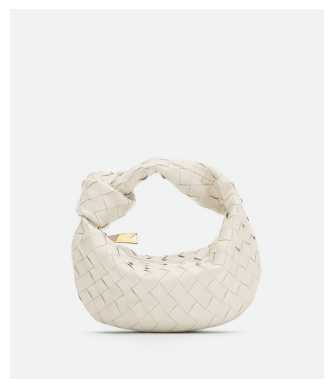

Predicted Class: bottega_venetta_jodie
bottega_venetta_jodie: 99.97%
chanel_255: 0.03%



Image: chanel_255_test3.jpeg


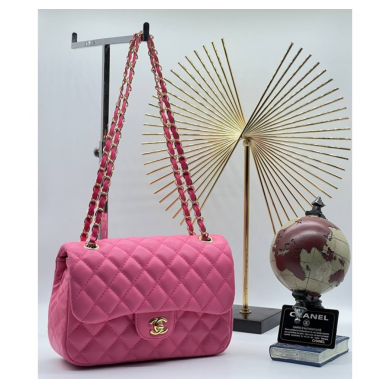

Predicted Class: chanel_255
bottega_venetta_jodie: 2.31%
chanel_255: 97.69%



Image: chanel_255_test2.jpg


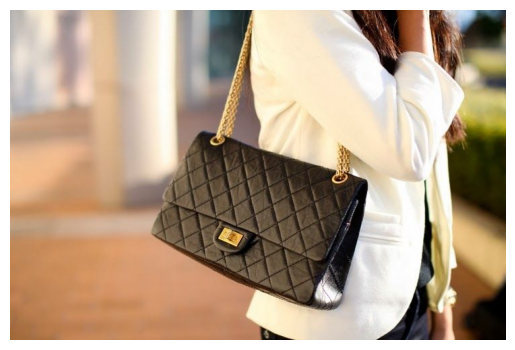

Predicted Class: chanel_255
bottega_venetta_jodie: 0.08%
chanel_255: 99.92%


In [14]:
# What are the probabilities of different classes for this image?
##### YOUR CODE STARTS #####
class_names = learn.dls.vocab
for test_img in test_path.glob("*"):
  img = PILImage.create(test_img)
  pred_class, pred_idx, probs = learn.predict(img)

  print(f"\nImage: {test_img.name}")
  plt.imshow(img)
  plt.axis("off")
  plt.show()
  print(f"Predicted Class: {pred_class}")
  for i, class_name in enumerate(class_names):
    print(f"{class_name}: {[float(f'{p:.6f}') for p in probs.numpy()][i]*100:.2f}%")
##### YOUR CODE ENDS #####

# Bonus exercises
*(NB, these are optional exercises!)*

## Bonus exercise 1 (2 bonus points):

<font color='red'> [Stable Diffusion](https://stability.ai/blog/stable-diffusion-announcement) model has been recently shown to produce trully impressive results in image generation. Let's explore some of its power in this auxiliarly exercise. Use Stable Diffusion model from this [colab](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/stable_diffusion.ipynb?hl=en). Generate several tricky images to test the model you trained in the exercise 3. Report the images that you have generated with Stable Diffusion, prompt that you have used for generating them, the number of iterations that you used to generate images and the classification results from your CNN model. Shortly summarise the results you have obtained. </font>

In [15]:
!pip install diffusers transformers scipy ftfy accelerate
!pip install fastai torch torchvision

import torch
from diffusers import StableDiffusionPipeline
from fastai.vision.all import *
from pathlib import Path
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [16]:
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", torch_dtype=torch.float16)
pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

scheduler_config-checkpoint.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [17]:
prompts = [
    "A luxury handbag blending elements of Bottega Veneta Jodie and Chanel 255",
    "A futuristic handbag with elements of classic Bottega Veneta design",
    "A Chanel-inspired handbag made of metal with an organic texture"
]

gen_path = Path("/content/generated_bags")
gen_path.mkdir(parents=True, exist_ok=True)

generated_images = []
num_iterations = 50

for i, prompt in enumerate(prompts):
    print(f"Generating image {i+1} for prompt: {prompt}")
    image = pipe(prompt, num_inference_steps=num_iterations).images[0]
    img_path = gen_path / f"generated_{i+1}.png"
    image.save(img_path)
    generated_images.append(img_path)
    print(f"Image saved at: {img_path}")

Generating image 1 for prompt: A luxury handbag blending elements of Bottega Veneta Jodie and Chanel 255


  0%|          | 0/50 [00:00<?, ?it/s]

Image saved at: /content/generated_bags/generated_1.png
Generating image 2 for prompt: A futuristic handbag with elements of classic Bottega Veneta design


  0%|          | 0/50 [00:00<?, ?it/s]

Image saved at: /content/generated_bags/generated_2.png
Generating image 3 for prompt: A Chanel-inspired handbag made of metal with an organic texture


  0%|          | 0/50 [00:00<?, ?it/s]

Image saved at: /content/generated_bags/generated_3.png



Image: generated_1.png


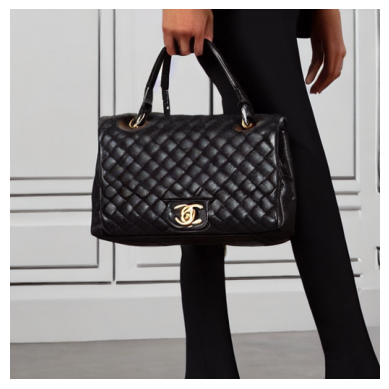

Predicted Class: chanel_255
bottega_venetta_jodie: 0.14%
chanel_255: 99.86%



Image: generated_2.png


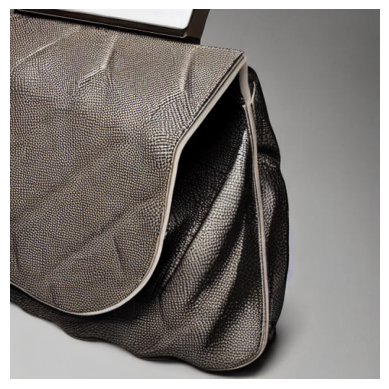

Predicted Class: bottega_venetta_jodie
bottega_venetta_jodie: 99.74%
chanel_255: 0.26%



Image: generated_3.png


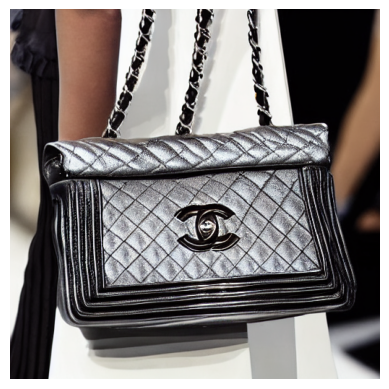

Predicted Class: chanel_255
bottega_venetta_jodie: 0.00%
chanel_255: 100.00%


In [18]:
for test_img in generated_images:
  img = PILImage.create(test_img)
  pred_class, pred_idx, probs = learn.predict(img)

  print(f"\nImage: {test_img.name}")
  plt.imshow(img)
  plt.axis("off")
  plt.show()
  print(f"Predicted Class: {pred_class}")
  for i, class_name in enumerate(class_names):
    print(f"{class_name}: {[float(f'{p:.6f}') for p in probs.numpy()][i]*100:.2f}%")

I tested our handbag classifier on three AI-generated bags, and honestly, it did such a good job!

The first bag was meant to be a mix of Bottega Veneta Jodie and Chanel 255, but the model instantly called it Chanel — which makes sense with that quilted pattern and iconic clasp.

The second was a futuristic Bottega-inspired design, and the model nailed it! Even with a modern twist, the soft leather folds and slouchy shape were unmistakably Bottega Veneta Jodie.

The last one was a metallic Chanel-inspired bag, and the model didn’t hesitate for a second — quilted leather and chain straps? Definitely Chanel 255.

So overall, the model is obsessed with key design features, which worked great here, but I’m not sure ResNet-34 would do as well with Hermes Birkin and Kelly bags. Their different leather textures, finishes, and subtle craftsmanship details might be tricky since ResNet focuses more on shapes and patterns due to general residual connections. A better approach could be Vision Transformers or hybrid CNN-ViT models, I guess, something like that https://viso.ai/deep-learning/vision-transformer-vit/

## Bonus exercise 2 (2 bonus points):

<font color='red'> Take the code of the 3-layer network that you have constructed in the homework exercise 1, and substitute all ReLu activations with sigmoid. Change the corresponding feed-forward and backward paths to account for this change. Then run as many iterations (epochs) as we have in exercise 1 and report the resulting performance (accuracy). Visualise the obtained classifier and interpret the results. Did the network with sigmoid perform better or worse? </font>

In [26]:
h = 100

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  return x * (1 - x)

# first hidden layer
W = 0.01 * np.random.randn(D, h)
b = np.zeros((1, h))

# second hidden layer
W2 = 0.01 * np.random.randn(h, h)
b2 = np.zeros((1, h))

# output layer
W3 = 0.01 * np.random.randn(h, K)
b3 = np.zeros((1, K))

# hyperparameters
learning_rate = 1e-0
num_examples = X.shape[0]

for i in range(2000):
  # forward path
  hidden_layer = sigmoid(X @ W + b)
  hidden_layer_2 = sigmoid(hidden_layer @ W2 + b2)
  scores = hidden_layer_2 @ W3 + b3

  # error
  exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
  predictions = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
  total_error = -np.sum(truth * np.log(predictions + 1e-8)) / num_examples

  if i % 100 == 0:
      print("iteration %d: loss %e" % (i, total_error))

  # backpropagation
  dTEdP = (predictions - truth) / num_examples

  # backprop into parameters W3, b3
  dW3 = hidden_layer_2.T @ dTEdP
  db3 = np.sum(dTEdP, axis=0, keepdims=True)

  # backprop into W2, b2
  dH2 = dTEdP @ W3.T * sigmoid_derivative(hidden_layer_2)
  dW2 = hidden_layer.T @ dH2
  db2 = np.sum(dH2, axis=0, keepdims=True)

  # backprop into W, b
  dH = dH2 @ W2.T * sigmoid_derivative(hidden_layer)
  dW = X.T @ dH
  db = np.sum(dH, axis=0, keepdims=True)

  # parameter update
  W3 -= learning_rate * dW3
  b3 -= learning_rate * db3
  W2 -= learning_rate * dW2
  b2 -= learning_rate * db2
  W -= learning_rate * dW
  b -= learning_rate * db

iteration 0: loss 6.950138e-01
iteration 100: loss 6.927355e-01
iteration 200: loss 6.887759e-01
iteration 300: loss 6.480199e-01
iteration 400: loss 4.840659e-01
iteration 500: loss 4.051930e-01
iteration 600: loss 3.896215e-01
iteration 700: loss 3.862582e-01
iteration 800: loss 3.854282e-01
iteration 900: loss 3.851799e-01
iteration 1000: loss 3.850734e-01
iteration 1100: loss 3.850026e-01
iteration 1200: loss 3.849410e-01
iteration 1300: loss 3.848817e-01
iteration 1400: loss 3.848231e-01
iteration 1500: loss 3.847648e-01
iteration 1600: loss 3.847068e-01
iteration 1700: loss 3.846490e-01
iteration 1800: loss 3.845915e-01
iteration 1900: loss 3.845343e-01


In [28]:
hidden_layer = sigmoid(X @ W + b)
hidden_layer_2 = sigmoid(hidden_layer @ W2 + b2)
predictions = hidden_layer_2 @ W3 + b3
predicted_class = np.argmax(predictions, axis=1)
print('training accuracy: %.2f' % (np.mean(predicted_class == y[:, 0])))

training accuracy: 0.73


In [34]:
def plot_deep_neural_network(X, y, W, b, W2, b2, W3, b3):
  st = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, st),
                        np.arange(y_min, y_max, st))
  input_data = np.c_[xx.ravel(), yy.ravel()]

  hidden_layer = sigmoid(input_data @ W + b)
  hidden_layer_2 = sigmoid(hidden_layer @ W2 + b2)
  Z = np.dot(hidden_layer_2, W3) + b3

  Z = np.argmax(Z, axis=1)
  Z = Z.reshape(xx.shape)
  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors='white', cmap=plt.cm.Spectral)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show()

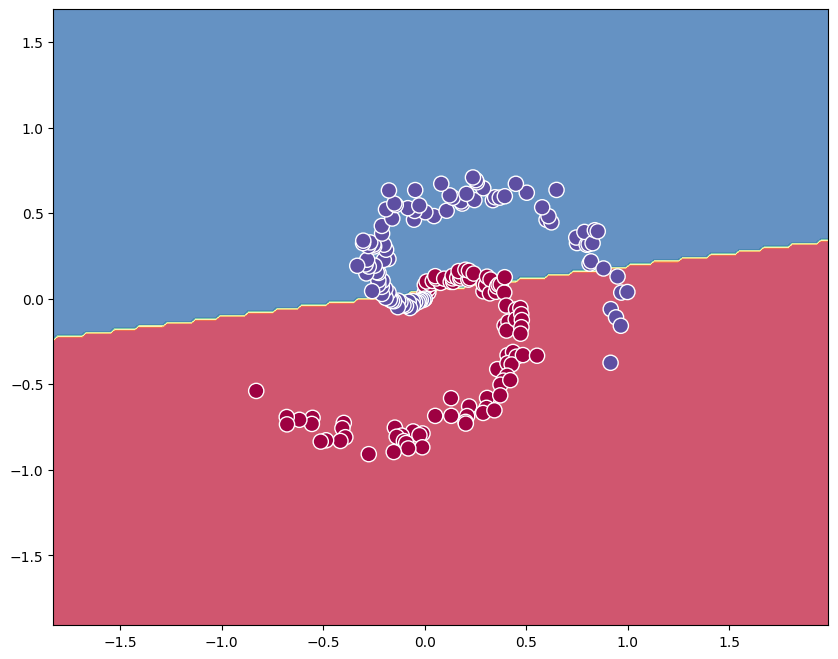

In [35]:
plot_deep_neural_network(X, y, W, b, W2, b2, W3, b3)

The ReLU network performed way better, hitting 99% accuracy, while the sigmoid version only managed 73%. The difference can be seen in the decision boundaries — ReLU captures the complex spiral shape perfectly, while sigmoid struggles and creates a more linear separation.

ReLU works better because it allows the model to learn deeper patterns without getting stuck with small gradient updates, unlike sigmoid, which squashes values and weakens learning. That’s why modern deep learning models almost always prefer ReLU over sigmoid or anything else.

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you spend on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

It took no more than 5 hours to complete, including bonus tasks and coffee breaks. There was a lot of repetition of the practices that were covered in the lectures. I would have been happy to see such topics like alternative loss functions, optimization techniques (Adam vs SGD, adaptive learning rate schedulers, etc.), hyperparameter tuning, and deeper architectures.
Interesting theoretical part in the bonus assignment about diffusion models :)

# <font color='red'>  End of the homework. Please don't delete this cell.</font>